In [1]:
# 7.6 Q1 - House Purchase Decision Tree (age + income)

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import (confusion_matrix, accuracy_score,
    classification_report)

In [3]:
df = pd.read_csv('datasets/house_purchase.csv')
print("Shape:", df.shape)
print(df.head(10))
print()
print("Class distribution:")
print(df['buys_house'].value_counts())

Shape: (400, 3)
   age  income  buys_house
0   24  199645           0
1   54  159932           0
2   49   77675           0
3   39  194928           1
4   39  109875           0
5   58  110133           0
6   23   98065           0
7   51   45901           0
8   29  188187           0
9   24   22508           1

Class distribution:
buys_house
1    253
0    147
Name: count, dtype: int64


In [4]:
X = df[['age', 'income']]
y = df['buys_house']
print("X shape:", X.shape, "y shape:", y.shape)

X shape: (400, 2) y shape: (400,)


In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)
print("Train:", X_train.shape, "Test:", X_test.shape)

Train: (280, 2) Test: (120, 2)


In [6]:
model = DecisionTreeClassifier(criterion='entropy', max_depth=3,
                                random_state=42)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print()
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))
print()
print(classification_report(y_test, y_pred))

Accuracy: 0.7916666666666666

Confusion Matrix:
[[24 20]
 [ 5 71]]

              precision    recall  f1-score   support

           0       0.83      0.55      0.66        44
           1       0.78      0.93      0.85        76

    accuracy                           0.79       120
   macro avg       0.80      0.74      0.75       120
weighted avg       0.80      0.79      0.78       120



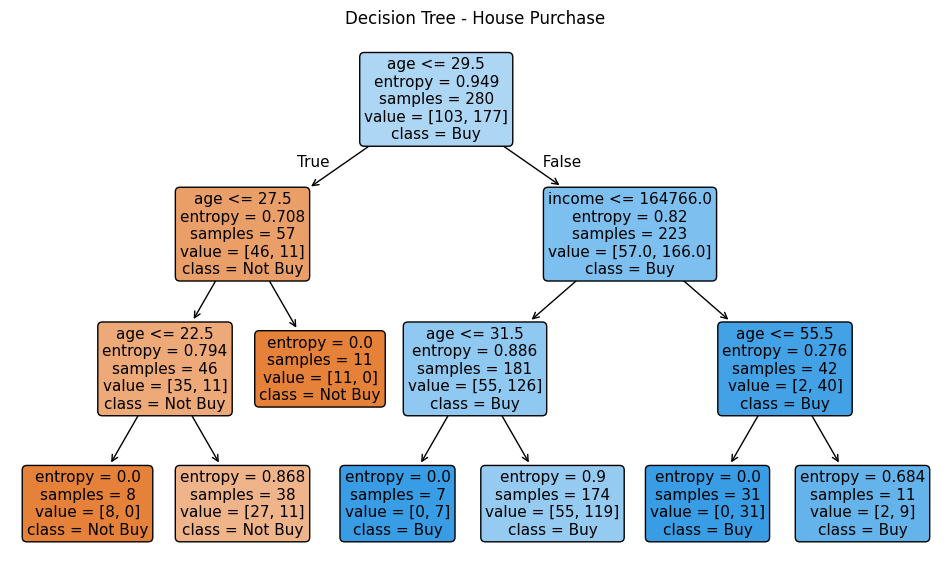

In [7]:
plt.figure(figsize=(12, 7))
plot_tree(model, feature_names=['age', 'income'],
          class_names=['Not Buy', 'Buy'],
          filled=True, rounded=True, fontsize=11)
plt.title('Decision Tree - House Purchase')
plt.show()

In [8]:
# Decision boundary

/home/z/.venv/lib/python3.12/site-packages/sklearn/base.py:493: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


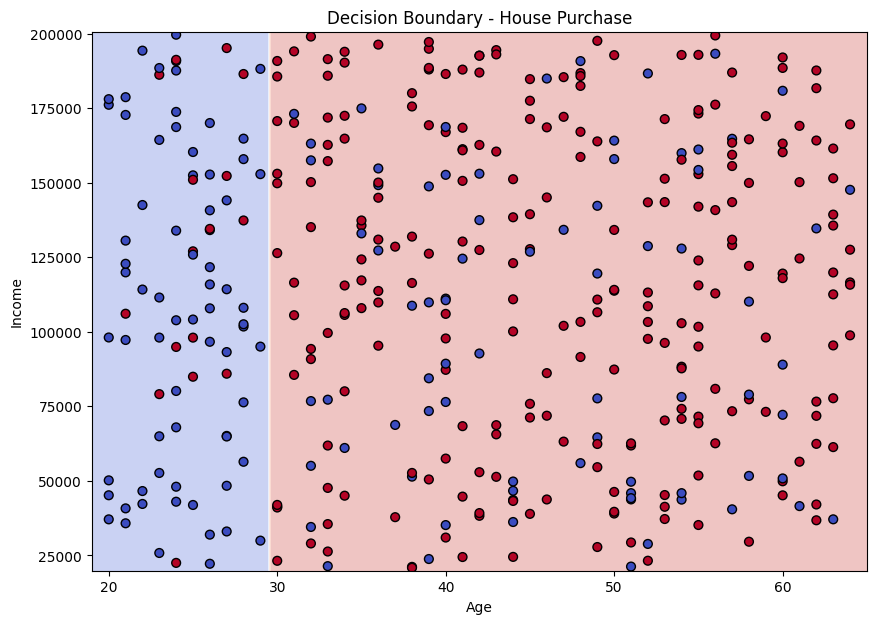

In [9]:
x_min, x_max = df['age'].min()-1, df['age'].max()+1
y_min, y_max = df['income'].min()-1000, df['income'].max()+1000
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200),
                    np.linspace(y_min, y_max, 200))
Z = model.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

plt.figure(figsize=(10, 7))
plt.contourf(xx, yy, Z, alpha=0.3, cmap='coolwarm')
plt.scatter(df['age'], df['income'], c=df['buys_house'],
            cmap='coolwarm', edgecolors='k', s=40)
plt.xlabel('Age')
plt.ylabel('Income')
plt.title('Decision Boundary - House Purchase')
plt.show()